# 22. SHAP fingerprints of the crises (research question 2)
Notebook 21 explained one day with one model. The study explained **every day in each crisis window plus every 10th calm day — 1,547 days — with all 5 models** of the year (about 20 minutes of computing). Here we load those results and test the hypotheses H2a–H2e.

* **Needs:** `results/shap_channel_shares.csv`, `results/shap_input_types.csv`, `results/shap_lags.csv`. **Makes:** nothing new.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

In [2]:
from pandas import read_csv
shap = read_csv(folder + 'results/shap_channel_shares.csv')
shap

,window,channel,days,share,ci_low,ci_high,mean_abs_attribution_per_day
0,calm,domestic,294,0.522787,0.501857,0.541383,0.931894
1,calm,US,294,0.266482,0.256407,0.278580,0.475018
2,calm,euro,294,0.210731,0.194697,0.226050,0.375640
3,Global Financial Crisis,domestic,402,0.481979,0.448055,0.508857,1.656382
4,Global Financial Crisis,US,402,0.299078,0.282273,0.320591,1.027818
5,Global Financial Crisis,euro,402,0.218943,0.202919,0.238288,0.752427
6,Irish sovereign debt crisis,domestic,574,0.512013,0.493158,0.531962,0.968267
7,Irish sovereign debt crisis,US,574,0.251884,0.238806,0.265857,0.476338
8,Irish sovereign debt crisis,euro,574,0.236102,0.220279,0.252791,0.446493
9,COVID-19,domestic,92,0.488357,0.468477,0.508392,1.350023


Each row: a window, a channel, its **share** of the total |contribution|, and a **95% interval** (`ci_low` to `ci_high`).

**How the interval was made (block bootstrap):** draw the explained days again at random — in blocks of 10 neighbouring days, because neighbouring days are alike — recompute the share, repeat 1,000 times, and keep the middle 95% of the results. It shows how much the share could change by chance.

In [3]:
order = ['calm', 'Global Financial Crisis', 'Irish sovereign debt crisis', 'COVID-19', 'War / energy shock 2022']
share = shap.pivot(index='window', columns='channel', values='share').loc[order, ['domestic', 'US', 'euro']]
low = shap.pivot(index='window', columns='channel', values='ci_low').loc[order, ['domestic', 'US', 'euro']]
share.round(3)

channel,domestic,US,euro
window,,,
calm,0.523,0.266,0.211
Global Financial Crisis,0.482,0.299,0.219
Irish sovereign debt crisis,0.512,0.252,0.236
COVID-19,0.488,0.332,0.180
War / energy shock 2022,0.540,0.317,0.143


<Axes: title={'center': 'Channel shares by window (the fingerprints)'}, xlabel='window'>

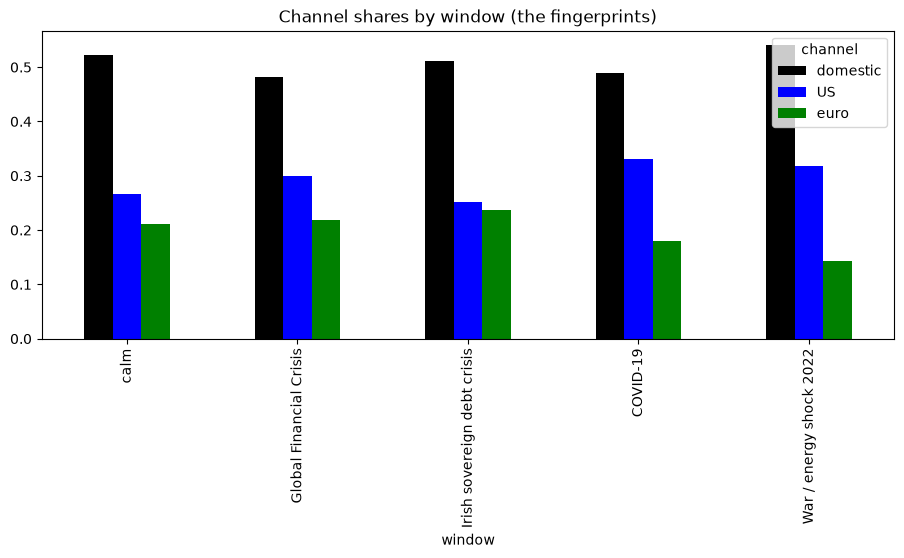

In [4]:
share.plot(kind='bar', figsize=(11, 4), color=['black', 'blue', 'green'], title='Channel shares by window (the fingerprints)')

## The rule (written before the results)
A channel **rises** in a crisis if the **lower end of its interval** is **above** its share in calm times.

In [5]:
for window in ['Global Financial Crisis', 'Irish sovereign debt crisis', 'COVID-19', 'War / energy shock 2022']:
    for channel in ['domestic', 'US', 'euro']:
        if low.loc[window, channel] > share.loc['calm', channel]:
            print(window, '-', channel, ': RISES')
        else:
            print(window, '-', channel, ': does not rise')

Global Financial Crisis - domestic : does not rise
Global Financial Crisis - US : RISES
Global Financial Crisis - euro : does not rise
Irish sovereign debt crisis - domestic : does not rise
Irish sovereign debt crisis - US : does not rise
Irish sovereign debt crisis - euro : RISES
COVID-19 - domestic : does not rise
COVID-19 - US : RISES
COVID-19 - euro : does not rise
War / energy shock 2022 - domestic : does not rise
War / energy shock 2022 - US : RISES
War / energy shock 2022 - euro : does not rise


## H2a — Global Financial Crisis: the US share rises the most, and the domestic share is above calm

In [6]:
change = share.loc['Global Financial Crisis'] - share.loc['calm']
print(change.round(3))
us_rises_most = change.idxmax() == 'US'
us_rises = low.loc['Global Financial Crisis', 'US'] > share.loc['calm', 'US']
domestic_rises = low.loc['Global Financial Crisis', 'domestic'] > share.loc['calm', 'domestic']
print('US rises most:', us_rises_most, '| US rises:', us_rises, '| domestic rises:', domestic_rises)
print('H2a supported:', us_rises_most and us_rises and domestic_rises)

channel
domestic   -0.041
US          0.033
euro        0.008
dtype: float64
US rises most: True | US rises: True | domestic rises: False
H2a supported: False


The US share rises most — but the domestic share **falls**, so H2a is only partly met.

## H2b — Irish debt crisis: euro and domestic rise; the US share is below its GFC level

In [7]:
euro_rises = low.loc['Irish sovereign debt crisis', 'euro'] > share.loc['calm', 'euro']
domestic_rises = low.loc['Irish sovereign debt crisis', 'domestic'] > share.loc['calm', 'domestic']
us_below_gfc = share.loc['Irish sovereign debt crisis', 'US'] < share.loc['Global Financial Crisis', 'US']
print('euro rises:', euro_rises, '| domestic rises:', domestic_rises, '| US below GFC:', us_below_gfc)
print('H2b supported:', euro_rises and domestic_rises and us_below_gfc)

euro rises: True | domestic rises: False | US below GFC: True
H2b supported: False


## H2c — COVID-19: the shares move towards equality
Measured by the gap between the largest and the smallest share (smaller gap = more equal).

In [8]:
gap_covid = share.loc['COVID-19'].max() - share.loc['COVID-19'].min()
gap_calm = share.loc['calm'].max() - share.loc['calm'].min()
print('gap in COVID =', round(gap_covid, 3), '| gap in calm =', round(gap_calm, 3))
print('H2c supported:', gap_covid < gap_calm)

gap in COVID = 0.308 | gap in calm = 0.312
H2c supported: True


Supported — but only just (0.308 vs 0.312).

## H2e — 2022 war / energy shock: the euro share rises

In [9]:
print('H2e supported:', low.loc['War / energy shock 2022', 'euro'] > share.loc['calm', 'euro'])

H2e supported: False


The euro share actually **falls** in 2022 (0.211 → 0.143) while the US share rises.

In [10]:
saved = read_csv(folder + 'results/shap_hypotheses.csv')
saved

,hypothesis,supported
0,H2a GFC: US share rises most; domestic above calm,False
1,H2b Irish debt crisis: euro and domestic rise;...,False
2,H2c COVID: shares move towards equality (small...,True
3,H2e 2022 shock: euro share rises,False
4,H4 stability: mean pairwise Spearman >= 0.8 in...,False


## Direction or size? And how far back?

In [11]:
types = read_csv(folder + 'results/shap_input_types.csv', index_col=0)
types.round(3)

,size (squared returns),direction (returns)
window,,
calm,0.590,0.410
Global Financial Crisis,0.380,0.620
Irish sovereign debt crisis,0.655,0.345
COVID-19,0.510,0.490
War / energy shock 2022,0.561,0.439


In the GFC, **62%** of the explanation is on the returns (the **direction** of the moves) against 41% in calm times: falls mattered more than the size of moves — the 'leverage effect'.

<Axes: title={'center': 'share of |contribution| by day of the window'}>

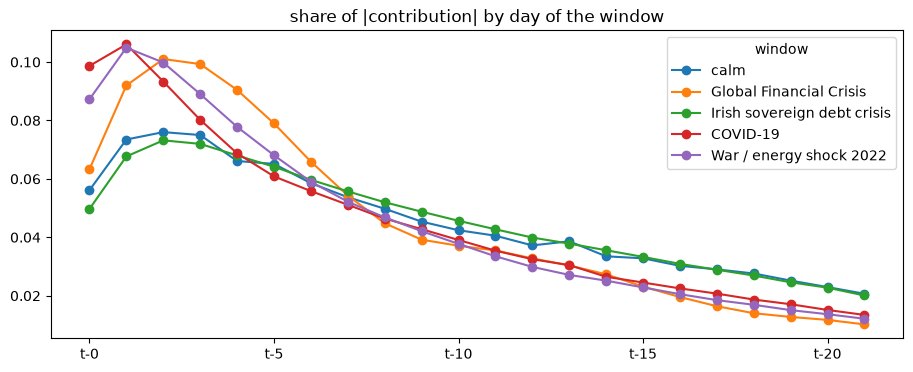

In [12]:
lags = read_csv(folder + 'results/shap_lags.csv', index_col=0)
lags.T.plot(figsize=(11, 4), marker='o', title='share of |contribution| by day of the window')

In the fast crises (GFC, COVID, 2022) the model looks mostly at the **last 1–5 days**; in the slow Irish debt crisis it looks back like in calm times.

**Remember:** SHAP describes **the model**, not the economy. The study therefore speaks of *fingerprints consistent with transmission*, never of proof of contagion.